<a href="https://colab.research.google.com/github/rahiakela/genai-research-and-practice/blob/main/rag-with-python-cookbook/07_rag_evaluation_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## RAG Evaluation Techniques


Evaluating a RAG system requires matching your metrics to the ground truth data you have available.

The full landscape of RAG evaluation metrics, organized into three groups:

* Generation metrics
  - Evaluate the generated answer for qualities like faithfulness, correctness, coherence,
fluency, and relevance.
* Retrieval metrics
  - Assess retrieval quality by using measures like recall, precision, and F1 score.
* General metrics
  - Capture system behavior such as latency and token usage.

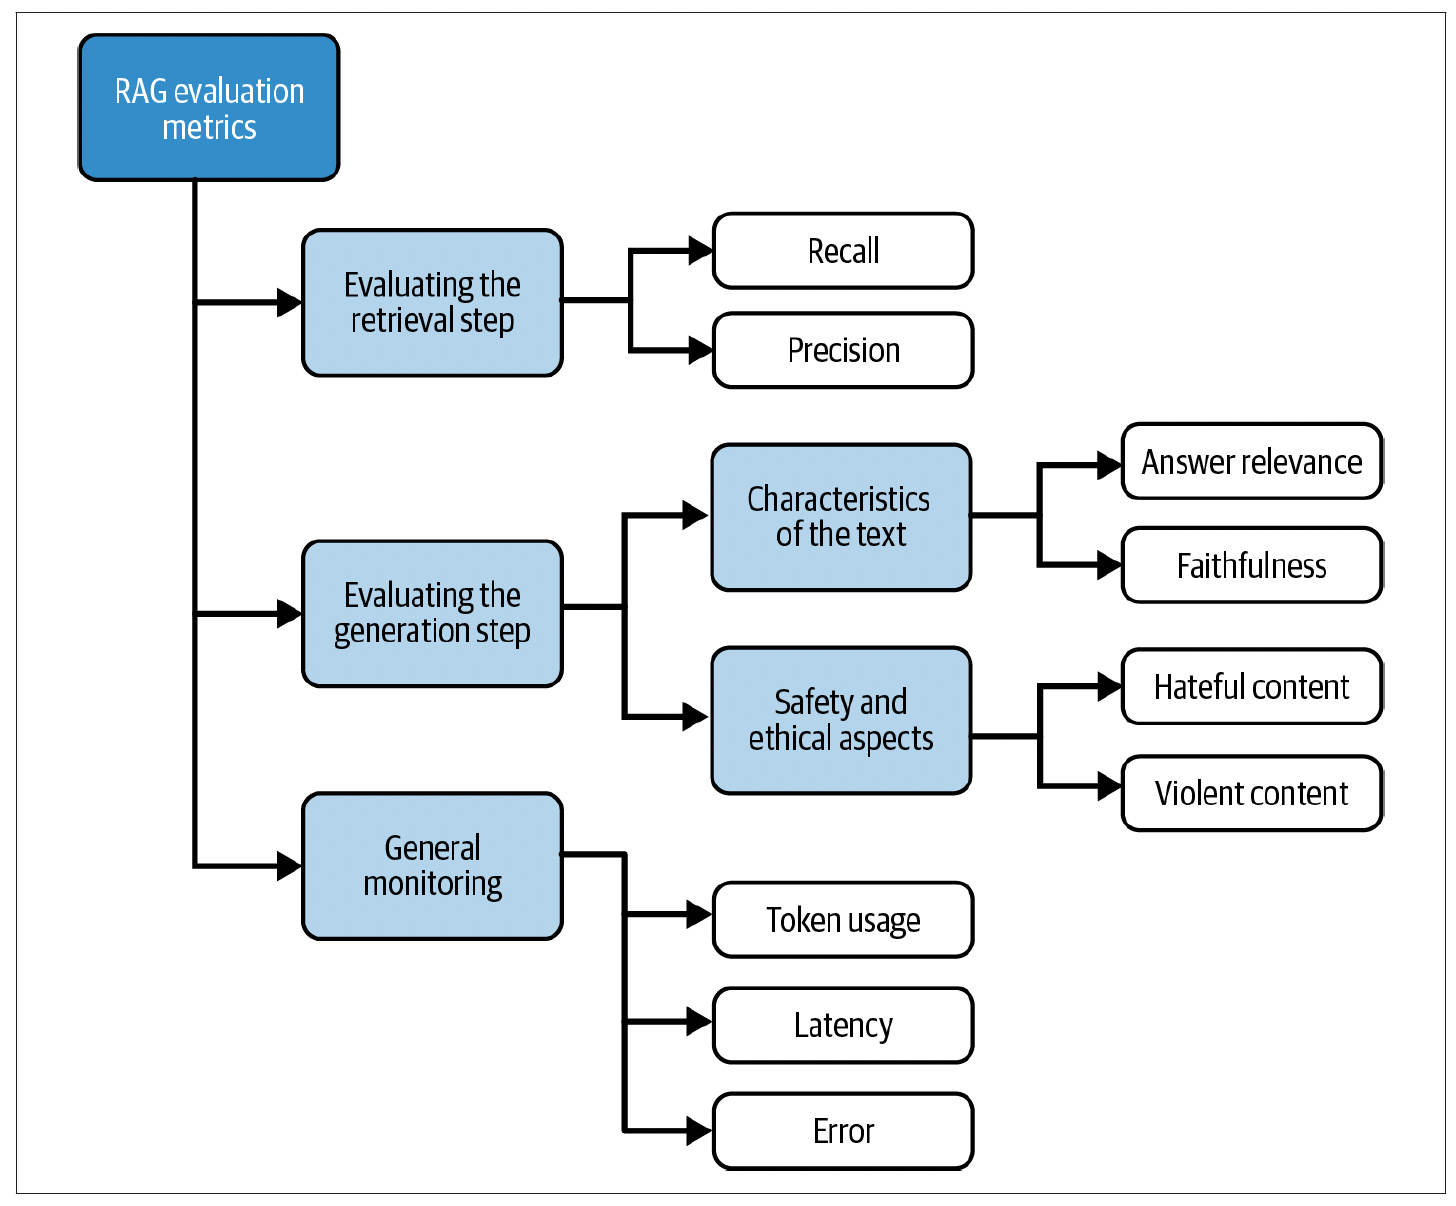

**Focus on three core metrics**

We will focuse on the common scenario in which you lack reference answers
but need automated evaluation. The approach uses LLM-as-judge—where one language
model evaluates the output of another—to assess three metrics that cover the
most critical failure modes in standard RAG systems. These metrics assume that the
retriever is a vector store returning similar text chunks.

For this case, the three metrics are as follows:
* Context precision
  - Measures the proportion of retrieved chunks that are actually relevant to the query. This metric targets the retrieval step and detects noise in your search results.
* Faithfulness
  - Measures whether the generated answer is strictly grounded in the provided context, avoiding hallucinations and unsupported claims. This metric targets the generation step and catches when the model invents information.
* Answer relevancy
  - Measures whether the generated answer directly addresses the user’s question. This metric targets the generation step and identifies misdirection—cases where the answer is factual but doesn’t help the user.

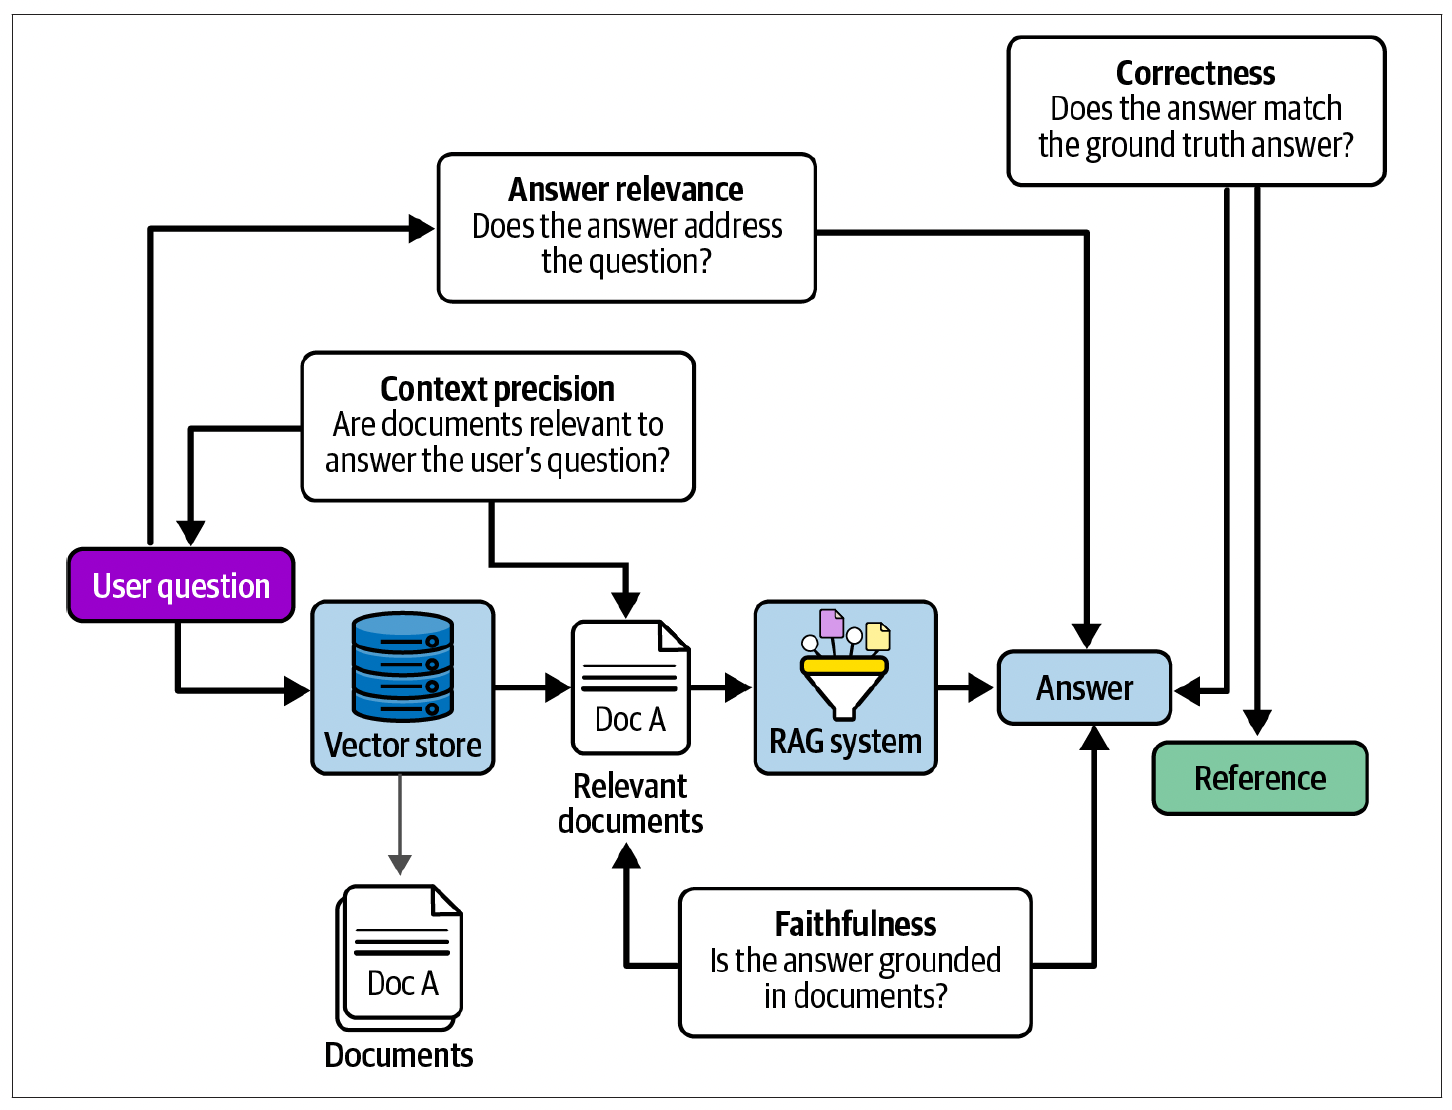

## Prerequisits

If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to uncomment and run the following codeblock to install the dependencies for this chapter.

In [ ]:
!pip install langchain-google-genai pydantic

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_google_genai import GoogleGenerativeAIEmbeddings

from google.colab import userdata

from numpy.linalg import norm
import pandas as pd
import numpy as np
import os

In [2]:
# --- Configuration ---
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

In [3]:
# Initialize the ChatGoogleGenerativeAI model
# Use a model that supports audio input, like "gemini-1.5-flash" or "gemini-1.5-pro"
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, api_key=userdata.get("GOOGLE_API_KEY") )

gemini_embeddings = GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")

## 1.Creating Synthetic Data for Automated Testing

You need a set of question-answer pairs that are suitable for testing your RAG solution.

**Solution**

The fastest and most practical approach is to use an LLM to automatically generate
synthetic question-answer pairs.

You can select random
text chunks from your vector store, then prompt an LLM to generate questions that
can be answered from those chunks. You can use single chunks or combine multiple
chunks as context. This creates test data at scale without manual labeling.

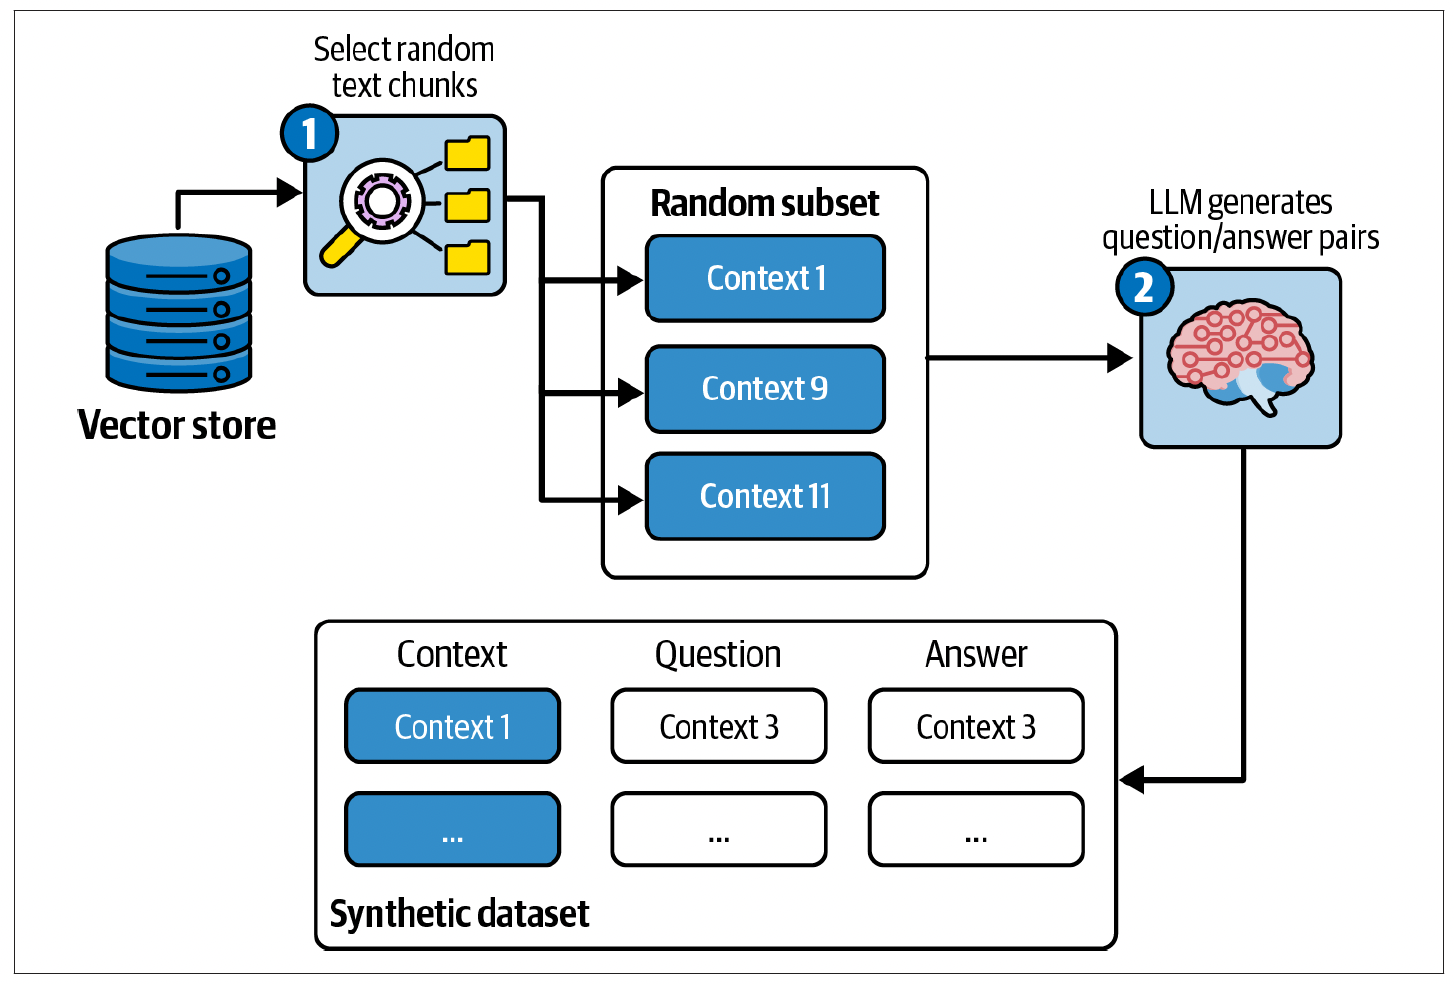

Let's start by loading the RAG mini Wikipedia dataset from Hugging Face.

In [4]:
import pandas as pd

df = pd.read_parquet(
    "hf://datasets/rag-datasets/rag-mini-wikipedia/data/"
    "passages.parquet/part.0.parquet"
)

docs_list = df.passage.to_list()

In [5]:
print(f"Number of documents: {len(docs_list)}")
print(f"List of docs:{docs_list}")

Number of documents: 3200
List of docs:['Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in the capital Montevideo and its metropolitan area.', 'It is bordered by Brazil to the north, by Argentina across the bank of both the Uruguay River to the west and the estuary of RÃ\xado de la Plata to the southwest, and the South Atlantic Ocean to the southeast. It is the second smallest independent country in South America, larger only than Suriname and the French overseas department of French Guiana.', 'Montevideo was founded by the Spanish in the early 18th century as a military stronghold. Uruguay won its independence in 1828 following a three-way struggle between Spain, Argentina and Brazil. It is a constitutional democracy, where the president fulfills the roles of both head of state and head of government', 'The economy is largely based in a

The next step is to randomly pick text chunks from the document list and instruct an
LLM to generate realistic questions and answers based on the information in those
chunks.

The prompt you use to instruct the LLM should have two parts:
* An instruction section telling the model what to do
* The context the model should use to generate questions and answers

In the instruction part, tell the model to think like a normal user and come up with
natural queries that a real user would ask.

In [6]:
from pydantic import BaseModel

QA_generation_prompt = """
    Your task is to generate a question and its corresponding answer based on the
    provided context.

    The question should be:
    - Direct and focused, seeking a specific factual piece of information present
        in the context.
    - Formulated as a natural query a user might input into a search engine.
    - Independent of the context, meaning it should not contain phrases like
        "according to the passage" or "in the context".

    The answer should be:
    - A concise and accurate response directly extracted or inferred from the context.

    Present your output in the following format:

    Output:
    Question: (Your concise, fact-based question)
    Answer: (The direct answer to the question)

    Context: {context}\n
    Output:"""


Next, define a response template as a Pydantic model. The returned Python object is a
question-answer pair, with both fields represented as strings.

The second part of the
snippet then picks five random text chunks from the overall dataset, iterates over
them, and generates question-answer pairs in the specified Pydantic format.

In [9]:

from pydantic import Field
import random

class QuestionAnswerPairs(BaseModel):
    question: str = Field(description="A factoid question about the context.")
    answer: str = Field(description="The answer to the factoid question.")

question_answer_pairs = []

random_text_chunks = random.sample(docs_list, 5)

for text_chunk in random_text_chunks:
    # generate hypothetical questions
    messages=[
        {
            "role": "user",
            "content": QA_generation_prompt.format(context=text_chunk),
        }
    ]

    structured_llm = llm.with_structured_output(QuestionAnswerPairs)
    completion = structured_llm.invoke(messages)
    print(completion)

    question_answer_pair = completion.model_dump()
    question_answer_pair["context"] = text_chunk
    question_answer_pairs.append(question_answer_pair)

question='Where was Pascal buried?' answer='Saint-Ã‰tienne-du-Mont'
question='Who was nominated by the Democratic party in 1896?' answer='William Jennings Bryan'
question='What are the other subspecies under the old taxonomic division?' answer='The provided context does not list any specific subspecies under the old taxonomic division.'
question='When did James Watt have his critical insight about condensing steam in a separate chamber?' answer='1765'
question='Who was on the committee to draft the Declaration of Independence?' answer='Thomas Jefferson, Benjamin Franklin, Robert R. Livingston, Roger Sherman, and Adams.'


In [10]:
question_answer_pairs

[{'question': 'Where was Pascal buried?',
  'answer': 'Saint-Ã‰tienne-du-Mont',
  'context': "Pascal's epitaph in Saint-Ã\x89tienne-du-Mont, where he was buried"},
 {'question': 'Who was nominated by the Democratic party in 1896?',
  'answer': 'William Jennings Bryan',
  'context': 'Cleveland\'s agrarian and silverite enemies seized control of the Democratic party in 1896, repudiated his administration and the gold standard, and nominated William Jennings Bryan on a Silver Platform. Cleveland silently supported the National Democratic Party (United States) (or "Gold Democratic") third party ticket that promised to defend the gold standard, limit government, and oppose protectionism. The party won only 100,000 votes in the general election (just over 1 percent). Agrarians again nominated Bryan in 1900, but in 1904 the conservatives, with Cleveland\'s support, regained control of the Democratic Party and nominated Alton B. Parker.'},
 {'question': 'What are the other subspecies under the

These questions can now be used to evaluate the retriever, the generator, and overall
system performance. Because the questions were derived from the actual data, the
RAG system should be able to find the answer in the existing content.

If it cannot,
that is a clear sign that something is wrong.

### 2. Evaluating the Retriever step by calculating the Context Precision@k

In [ ]:
question = "What is the capital of France?"
answer = "The capital of France is Paris."
retrieved_contexts = ["""France, a country in Western Europe, is known for its capital city,
    Paris, which is a major European city and a global center for art, fashion,
    and culture.""",
    """Paris is the capital city of France and is renowned for its historical landmarks
    such as the Eiffel Tower and the Louvre Museum.""",
    """The Amazon rainforest is the world's largest tropical rainforest, spanning
    across nine South American countries and supporting immense biodiversity."""
]

In [ ]:
from textwrap import dedent
from pydantic import BaseModel, Field
from openai import OpenAI

def context_relevance_verification(question, answer, retrieved_contexts):
    # Pydantic model for verification
    class Verification(BaseModel):
        reason: str = Field(..., description="Reason for verification")
        verdict: int = Field(..., description="Binary (0/1) verdict of verification")

    # Define the prompt for context relevance verification
    context_relevance_prompt = dedent('''
        Given a question, an answer, and a context, verify if the context
        was instrumental in deriving the given answer. Provide a detailed reason
        for your assessment and a binary verdict: "1" if the context is useful
        and "0" if it is not.

        Input:
        Question: "{question}",
        Answer: "{answer}",
        Context: "{context}"
        ''')

    list_of_verifications = []

    # Iterate through each question-answer pair and its context
    for retrieved_context in retrieved_contexts:
        prompt = context_relevance_prompt.format(
                question=question,
                answer=answer,
                context=retrieved_context)

        client = OpenAI()
        completion = client.chat.completions.parse(
            messages=[
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            model="gpt-5.2",
            response_format=Verification,
        )

        verification = completion.choices[0].message.parsed.model_dump()
        verification["question"] = question
        verification["answer"] = answer
        verification["retrieved_context"] = retrieved_context

        list_of_verifications.append(verification)
    return list_of_verifications

In [ ]:
list_of_verifications = context_relevance_verification(
                                    question,
                                    answer,
                                    retrieved_contexts
                                )
list_of_verifications

[{'reason': 'The context explicitly states that France is known for its capital city, Paris. This directly supports and is sufficient to derive the answer that the capital of France is Paris, making the context instrumental to the response.',
  'verdict': 1,
  'question': 'What is the capital of France?',
  'answer': 'The capital of France is Paris.',
  'retrieved_context': 'France, a country in Western Europe, is known for its capital city,\n    Paris, which is a major European city and a global center for art, fashion,\n    and culture.'},
 {'reason': 'The context explicitly states that “Paris is the capital city of France.” This directly provides the key fact needed to answer the question about France’s capital, making it instrumental in deriving the answer.',
  'verdict': 1,
  'question': 'What is the capital of France?',
  'answer': 'The capital of France is Paris.',
  'retrieved_context': 'Paris is the capital city of France and is renowned for its historical landmarks\n    such 

In [ ]:
import pandas as pd

def calculate_context_relevance_score(list_of_verifications):
    verdict_list = pd.DataFrame(list_of_verifications)["verdict"].to_list()

    denominator = sum(verdict_list) + 1e-10
    numerator = sum(
        [
            (sum(verdict_list[: i + 1]) / (i + 1)) * verdict_list[i]
            for i in range(len(verdict_list))
        ]
    )
    score = numerator / denominator
    return score

In [ ]:
score = calculate_context_relevance_score(list_of_verifications)
score

0.99999999995

### 3. Evaluating RAG systems using LLMs as a judge and the Faithfulness Metrics

    """
    Decomposes the sentences in an answer into simpler, unambiguous statements.

    Args:
        question: The original question.
        answer: The answer to be decomposed.
        client: An initialized OpenAI client.

    Returns:
        A list of decomposed statements.
    """

In [ ]:
from textwrap import dedent
from pydantic import BaseModel, Field
from openai import OpenAI

def decompose_answer(question, answer):
    # Initialize the OpenAI client
    client = OpenAI()

    statement_prompt = """
    Given a question and an answer, analyze the complexity of each sentence
    in the answer. Break down each sentence into one or more fully
    understandable statements. Ensure that no pronouns or ambiguous references
    are used in any statement. Output the decomposed statements as a list of strings.

    Question: {question}
    Answer: {answer}
    """

    prompt = statement_prompt.format(question=question, answer=answer)

    class Statements(BaseModel):
        """Structured response for statement extraction."""

        statements: list[str] = Field(description="List of decomposed statements.")

    completion = client.chat.completions.parse(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="gpt-5.2",
        response_format=Statements,
    )

    statements = completion.choices[0].message.parsed.statements
    return statements

In [ ]:
question = """Describe the geographical extent and ecological significance of the
Amazon rainforest."""

answer = dedent("""
The Amazon rainforest, the world's largest tropical rainforest, covers significant
territory across nine South American countries. This vast area is renowned for
its immense biodiversity, supporting millions of different plant and animal species.
While it plays a crucial role in the global climate by absorbing substantial amounts
of carbon dioxide, its impact on the overall oxygen production of the Earth is often
overstated.
""")

In [ ]:
statements = decompose_answer(question, answer)

print("Decomposed Statements:")
for idx, stmt in enumerate(statements, 1):
    print(f"{idx}. {stmt}")

Decomposed Statements:
1. The Amazon rainforest is the world's largest tropical rainforest.
2. The Amazon rainforest covers significant territory across nine South American countries.
3. The Amazon rainforest spans territory in nine different South American countries.
4. The Amazon rainforest is a vast area.
5. The Amazon rainforest is renowned for immense biodiversity.
6. The Amazon rainforest supports millions of different plant species.
7. The Amazon rainforest supports millions of different animal species.
8. The Amazon rainforest plays a crucial role in the global climate.
9. The Amazon rainforest absorbs substantial amounts of carbon dioxide.
10. The impact of the Amazon rainforest on the overall oxygen production of the Earth is often overstated.


In [ ]:
from pydantic import BaseModel, Field
from textwrap import dedent
from openai import OpenAI

def judge_faithfulness(statement: str, context: str) -> list[dict]:

    # Initialize the OpenAI client
    client = OpenAI()

    faithfulness_judge_prompt = dedent(
        """
        Your task is to judge the faithfulness of a statement based on the
        given context. You must return a verdict as 1 if the statement can
        be directly inferred from the context, or 0 if the statement cannot
        be directly inferred. Explain your reasoning.

        Context:
        {context}

        Statement:
        {statement}

        Answer:::
        Reason: (Explain your reasoning)
        Verdict: (1 or 0)
        """
    )

    class StatementFaithfulness(BaseModel):
        """Structured response for statement extraction."""

        statements: str = Field(description="Decomposed statement.")
        reason: str = Field(description="Reasoning for the faithfulness judgement.")
        verdict: int = Field(
                        description="1 if the statement is faithful, 0 otherwise."
                        )

    prompt = faithfulness_judge_prompt.format(statement=statement, context=context)

    completion = client.chat.completions.parse(
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        model="gpt-5.2",
        response_format=StatementFaithfulness,
    )

    statement_faithfulness = completion.choices[0].message.parsed.model_dump()
    return statement_faithfulness

In [ ]:
statements_faithfulness = []

context = dedent(
    """
    The Amazon rainforest is the largest tropical rainforest in the world,
    covering parts of nine South American countries. It is known for its
    incredible biodiversity, housing millions of species of plants, insects,
    birds, and other animals. The forest plays a crucial role in regulating
    the Earth's climate by absorbing vast amounts of carbon dioxide.
    """
)

for statement in statements:
    statement_faithfulness = judge_faithfulness(
        statement=statement, context=context
    )
    # Append the statement faithfulness to the list
    statements_faithfulness.append(statement_faithfulness)

In [ ]:
print("Number of statements:", len(statements_faithfulness))
statements_faithfulness

Number of statements: 10


[{'statements': "The Amazon rainforest is the world's largest tropical rainforest.",
  'reason': 'The context explicitly states: "The Amazon rainforest is the largest tropical rainforest in the world," which directly matches the statement.',
  'verdict': 1},
 {'statements': 'The Amazon rainforest covers significant territory across nine South American countries.',
  'reason': 'The context states that the Amazon rainforest is the largest tropical rainforest in the world and that it covers parts of nine South American countries. This directly supports the claim that it spans territory across nine countries (the word “significant” is subjective but consistent with “covers parts of nine countries”).',
  'verdict': 1},
 {'statements': 'The Amazon rainforest spans territory in nine different South American countries.',
  'reason': 'The context states that the Amazon rainforest is "covering parts of nine South American countries," which directly supports the statement that it spans territory 

In [ ]:
import pandas as pd

statements_faith_df = pd.DataFrame(statements_faithfulness)

number_of_claims = len(statements_faith_df["verdict"])
number_of_claims_in_context = statements_faith_df["verdict"].sum()
faithfulness_percentage = (
    number_of_claims_in_context / number_of_claims
) * 100

In [ ]:
faithfulness_percentage

np.float64(90.0)

### 4. RAG evaluation using Response Relevancy

In [ ]:
user_input="What is the capital of France?"
response="The capital of France is Paris."

In [ ]:
from textwrap import dedent

response_relevance_prompt = dedent("""
    Generate three relevant question for the following answer
    and indicate if the answer is noncommittal.

    Output:
    Question: [Generated Question]
    Noncommittal (1=Yes, 0=No): [0 or 1]

    An answer is considered noncommittal if it is evasive, vague, or ambiguous
    (e.g., "I don't know," "Maybe," "It depends").

    Answer: {response}
    """)

In [ ]:
from pydantic import BaseModel, Field

prompt = response_relevance_prompt.format(response=response)

class GeneratedQuestion(BaseModel):
    question: str = Field(description="Generated question.")
    noncommittal: int = Field(
        description="1 if the answer is noncommittal, 0 otherwise."
    )

class GeneratedQuestions(BaseModel):
    questions: list[GeneratedQuestion] = Field(
        description="List of generated questions and their noncommittal status."
    )

client = OpenAI()

completion = client.chat.completions.parse(
    messages=[
        {
            "role": "user",
            "content": prompt,
        }
    ],
    model="gpt-5.2",
    response_format=GeneratedQuestions,
)

generated_questions = completion.choices[0].message.parsed.model_dump()["questions"]

In [ ]:
generated_questions

[{'question': 'What is the capital city of France?', 'noncommittal': 0},
 {'question': 'Which city serves as France’s capital and primary seat of government?',
  'noncommittal': 0},
 {'question': 'Is Paris the capital of France?', 'noncommittal': 0}]

In [ ]:
from openai import OpenAI

client = OpenAI()

def create_embeddings(text_chunk, client):
    embed_model = "text-embedding-3-small"
    embedding = (
        client.embeddings.create(input=[text_chunk], model=embed_model)
        .data[0]
        .embedding
    )
    return embedding

In [ ]:
user_input

'What is the capital of France?'

In [ ]:
user_question_embedding = create_embeddings(user_input, client)
cosine_sims = []

In [ ]:
import numpy as np
import pandas as pd

user_question_embedding = create_embeddings(user_input, client)
cosine_sims = []

for generated_question in generated_questions:
    generated_question["embedding"] = create_embeddings(
        generated_question["question"], client
    )

    generated_question["cosine_sim"] = np.dot(
        user_question_embedding, generated_question["embedding"]
    ) / (
        np.linalg.norm(user_question_embedding)
        * np.linalg.norm(generated_question["embedding"])
    )

In [ ]:
generated_question

{'question': 'Is Paris the capital of France?',
 'noncommittal': 0,
 'embedding': [0.00902880821377039,
  -0.00026706530479714274,
  -0.0037262921687215567,
  -0.024569392204284668,
  -0.015634171664714813,
  0.027367189526557922,
  -0.023387223482131958,
  -0.009230761788785458,
  -0.0014013616601005197,
  -0.0188949853181839,
  -0.021081997081637383,
  0.006329524330794811,
  -0.018225090578198433,
  0.02015596441924572,
  -0.04496179148554802,
  0.009225836023688316,
  -0.05292171984910965,
  0.045355845242738724,
  0.08322462439537048,
  -0.025731857866048813,
  0.029238956049084663,
  -0.0012634421000257134,
  -0.027800651267170906,
  0.04165171831846237,
  0.032450512051582336,
  0.017535492777824402,
  -0.01499383058398962,
  0.04413427412509918,
  0.0028347403276711702,
  0.0627337172627449,
  0.011733017861843109,
  -0.016491243615746498,
  -0.012678751721978188,
  0.03353416547179222,
  -0.03745502233505249,
  -0.04578930884599686,
  -0.005812325980514288,
  -0.03268694505095

In [ ]:
# calculate the mean cosine similarity over all generated questions
cosine_sim_mean = pd.DataFrame(generated_questions)["cosine_sim"].mean()

# check if any of the generated questions are non-committal
committal = any(pd.DataFrame(generated_questions)["noncommittal"])

# if any of the generated questions are non-committal, set the score to 0
response_relevance_score = cosine_sim_mean * int(not committal)

In [ ]:
response_relevance_score

np.float64(0.7983775700504806)